# Renewable Energy Share Analysis (SDG 7.2.1)
## A Comparative Study of Italy, Spain, and France (2000–2022)

### Project Overview

**Objective:**
Analyze renewable energy share (SDG 7.2.1) across selected European countries to identify growth patterns, compare performance, and assess variability over time.

**Dataset:**
United Nations SDG dataset (2000–2022), focusing on Italy, Spain, and France.

**Tools Used:**
Python (pandas, matplotlib, seaborn), SQL (SQLite), Excel

**Key Questions:**
- How has renewable energy adoption evolved over time?
- Which country shows the strongest growth?
- How consistent are the trends across countries?

**Author:** Luca Chiudioni

**Date:** November 2025

In [17]:
# Import libraries for data analysis and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import SQLite for SQL-based data querying
import sqlite3

# Set default visualization style
sns.set_theme(style="whitegrid")


## 1. Load the dataset

The dataset was downloaded from the official UN SDG Data Portal as an Excel file.  
Here I list the available sheets and load the one containing the actual indicator values.


In [18]:
# Load Excel file
file_path = "../data/SDG_Renewable_Energy.xlsx"

# Check available sheets
xls = pd.ExcelFile(file_path)
xls.sheet_names


['CodeDescriptions', 'Goal7']

In [19]:
# Load SDG Goal 7 data and perform initial data inspection
df = pd.read_excel(file_path, sheet_name="Goal7")
df.head()


,Goal,Target,Indicator,SeriesCode,SeriesDescription,GeoAreaCode,GeoAreaName,TimePeriod,Value,Time_Detail,TimeCoverage,UpperBound,LowerBound,BasePeriod,Source,GeoInfoUrl,FootNote,Nature,Reporting Type,Units
0,7,7.2,7.2.1,EG_FEC_RNEW,Renewable energy share in the total final ener...,1,World,2000,15.71,2000,NaN,NaN,NaN,NaN,"IEA (2024), World Energy Balances; Energy Bala...",NaN,NaN,N,G,PERCENT
1,7,7.2,7.2.1,EG_FEC_RNEW,Renewable energy share in the total final ener...,1,World,2001,15.41,2001,NaN,NaN,NaN,NaN,"IEA (2024), World Energy Balances; Energy Bala...",NaN,NaN,N,G,PERCENT
2,7,7.2,7.2.1,EG_FEC_RNEW,Renewable energy share in the total final ener...,1,World,2002,15.38,2002,NaN,NaN,NaN,NaN,"IEA (2024), World Energy Balances; Energy Bala...",NaN,NaN,N,G,PERCENT
3,7,7.2,7.2.1,EG_FEC_RNEW,Renewable energy share in the total final ener...,1,World,2003,15.21,2003,NaN,NaN,NaN,NaN,"IEA (2024), World Energy Balances; Energy Bala...",NaN,NaN,N,G,PERCENT
4,7,7.2,7.2.1,EG_FEC_RNEW,Renewable energy share in the total final ener...,1,World,2004,14.93,2004,NaN,NaN,NaN,NaN,"IEA (2024), World Energy Balances; Energy Bala...",NaN,NaN,N,G,PERCENT


## 2. Initial exploration and selection of relevant columns

The raw file contains multiple metadata fields.  
For this analysis, I keep only the following essential columns:
- `GeoAreaName` → country  
- `TimePeriod` → year  
- `Value` → renewable energy share (%)  
- `Units`, `Indicator`, `Source` → context information


In [20]:
# Inspect dataset structure, data types, and available columns
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6233 entries, 0 to 6232
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Goal               6233 non-null   int64  
 1   Target             6233 non-null   float64
 2   Indicator          6233 non-null   object 
 3   SeriesCode         6233 non-null   object 
 4   SeriesDescription  6233 non-null   object 
 5   GeoAreaCode        6233 non-null   int64  
 6   GeoAreaName        6233 non-null   object 
 7   TimePeriod         6233 non-null   int64  
 8   Value              6128 non-null   float64
 9   Time_Detail        6233 non-null   int64  
 10  TimeCoverage       0 non-null      float64
 11  UpperBound         0 non-null      float64
 12  LowerBound         0 non-null      float64
 13  BasePeriod         0 non-null      float64
 14  Source             6233 non-null   object 
 15  GeoInfoUrl         0 non-null      float64
 16  FootNote           105 n

Index(['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription',
       'GeoAreaCode', 'GeoAreaName', 'TimePeriod', 'Value', 'Time_Detail',
       'TimeCoverage', 'UpperBound', 'LowerBound', 'BasePeriod', 'Source',
       'GeoInfoUrl', 'FootNote', 'Nature', 'Reporting Type', 'Units'],
      dtype='object')

In [21]:
# Select relevant columns and rename them for clarity and consistency
keep_cols = ["Indicator", "GeoAreaName", "TimePeriod", "Value", "Units", "Source"]

sdg = df[keep_cols].rename(columns={
    "GeoAreaName": "country",
    "TimePeriod": "year",
    "Value": "value",
})

sdg.head()


,Indicator,country,year,value,Units,Source
0,7.2.1,World,2000,15.71,PERCENT,"IEA (2024), World Energy Balances; Energy Bala..."
1,7.2.1,World,2001,15.41,PERCENT,"IEA (2024), World Energy Balances; Energy Bala..."
2,7.2.1,World,2002,15.38,PERCENT,"IEA (2024), World Energy Balances; Energy Bala..."
3,7.2.1,World,2003,15.21,PERCENT,"IEA (2024), World Energy Balances; Energy Bala..."
4,7.2.1,World,2004,14.93,PERCENT,"IEA (2024), World Energy Balances; Energy Bala..."


## 3. Data cleaning

- Remove rows with missing values in the `value` column  
- Restrict the time period to a meaningful range (1990–2024)  
- Check for remaining missing values and units


In [22]:
# Assess data quality: check structure, missing values, and key variable distributions
sdg.info()
sdg.isna().mean().sort_values(ascending=False)
sdg["Units"].value_counts()
sdg["Indicator"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6233 entries, 0 to 6232
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicator  6233 non-null   object 
 1   country    6233 non-null   object 
 2   year       6233 non-null   int64  
 3   value      6128 non-null   float64
 4   Units      6233 non-null   object 
 5   Source     6233 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 292.3+ KB


array(['7.2.1'], dtype=object)

In [23]:
# Remove missing values and filter dataset to the selected time range
sdg = sdg.dropna(subset=["value"])
sdg = sdg[(sdg["year"] >= 1990) & (sdg["year"] <= 2024)]

sdg.shape


(6128, 6)

## 4. Country comparison: Italy, Spain, France (EDA)

This section compares the renewable energy share (%) for three major European countries.

The analysis reveals:
- Differences in long-term renewable energy adoption  
- Trends before and after 2010  
- Convergence or divergence between countries over time


In [24]:
# Filter dataset to selected countries for comparative analysis
countries = ["Italy", "Spain", "France"]
sdg_sel = sdg[sdg["country"].isin(countries)].copy()
sdg_sel.head()


,Indicator,country,year,value,Units,Source
2231,7.2.1,France,2000,9.27,PERCENT,"IEA (2024), World Energy Balances"
2232,7.2.1,France,2001,9.40,PERCENT,"IEA (2024), World Energy Balances"
2233,7.2.1,France,2002,8.68,PERCENT,"IEA (2024), World Energy Balances"
2234,7.2.1,France,2003,8.85,PERCENT,"IEA (2024), World Energy Balances"
2235,7.2.1,France,2004,8.90,PERCENT,"IEA (2024), World Energy Balances"


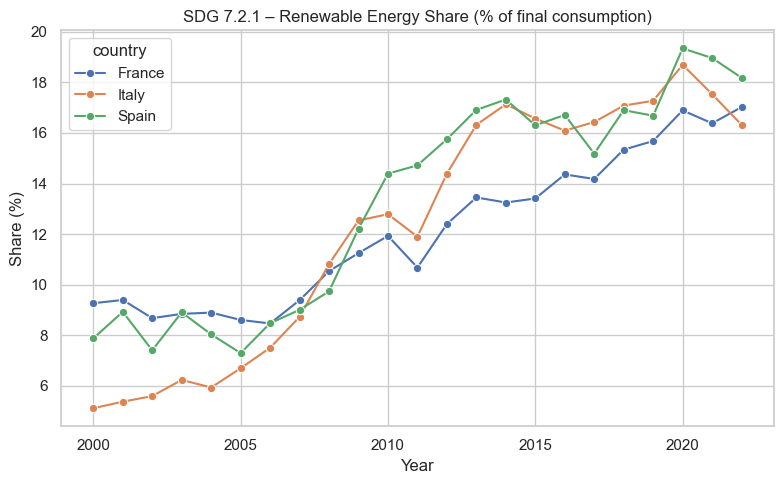

In [33]:
# Plot time-series trends of renewable energy share for selected countries
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=sdg_sel,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("SDG 7.2.1 – Renewable Energy Share (% of final consumption)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.tight_layout()
plt.savefig("../outputs/figures/renewable_energy_trends.png", dpi=300, bbox_inches="tight")
plt.show()


In [34]:
# Extract latest available values and rank countries by renewable energy share
latest = (
    sdg_sel.sort_values(["country", "year"])
           .groupby("country")
           .tail(1)
           .sort_values("value", ascending=False)
)
latest[["country", "year", "value"]].to_csv("../outputs/tables/latest_ranking.csv", index=False)
latest[["country", "year", "value"]]

,country,year,value
5335,Spain,2022,18.18
2253,France,2022,17.02
2966,Italy,2022,16.32


### 4.1. Total Growth in Renewable Energy Share (2000–2022)

In [36]:
# Calculate total and relative growth in renewable energy share by country and rank results
growth = sdg_sel.groupby("country").agg(
    start_value=("value", "first"),
    end_value=("value", "last")
    
)

growth["absolute_change"] = growth["end_value"] - growth["start_value"]
growth["relative_growth_%"] = (growth["absolute_change"] / growth["start_value"]) * 100

growth = growth.sort_values("absolute_change", ascending=False)
growth.reset_index().to_csv("../outputs/tables/growth_analysis.csv", index=False)
growth

,start_value,end_value,absolute_change,relative_growth_%
country,,,,
Italy,5.12,16.32,11.20,218.75000
Spain,7.88,18.18,10.30,130.71066
France,9.27,17.02,7.75,83.60302


**Preliminary insights:**
- **Between 2000 and 2022**, all three countries show a significant increase in renewable energy share. **Italy** experienced the highest absolute growth, increasing from **5.12%** to **16.32%** (**+11.20 percentage points**), followed by **Spain (+10.30 pp)** and **France (+7.75 pp)**.
- Despite starting from the lowest baseline, **Italy achieved the strongest overall growth**, indicating a faster long-term transition compared to France and Spain. It indeed increased by over **200%** relative to its initial level.
- By 2022, **Spain** reached the highest renewable energy share **(18.18%)**, followed by **France** **(17.02%)** and **Italy (16.32%)**, showing that higher growth does not necessarily translate into the highest final level.

### 4.2. Average Annual Growth Rate by Country

In [37]:
# Compute year-over-year changes and calculate average annual growth by country
sdg_sel = sdg_sel.sort_values(["country", "year"])

sdg_sel["yearly_change"] = sdg_sel.groupby("country")["value"].diff()

avg_growth = (
    sdg_sel.groupby("country")["yearly_change"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="avg_yearly_growth")
)
avg_growth.to_csv("../outputs/tables/avg_growth.csv", index=False)
avg_growth

,country,avg_yearly_growth
0,Italy,0.51
1,Spain,0.47
2,France,0.35


**Preliminary insights:**
- **Italy** shows **the highest average annual increase** in renewable energy share (**~0.51** percentage points per year), followed by **Spain (~0.47)**, while **France** exhibits a slower growth rate (**~0.35**).
- This confirms that Italy’s strong overall growth is driven by a **consistently higher yearly increase**, rather than isolated spikes.
- The average annual growth aligns with the total growth analysis, reinforcing **Italy as the fastest-growing country** over the period.

### 4.3. Volatility Analysis of Renewable Energy Trends

In [39]:
# Calculate standard deviation to assess variability (volatility) of renewable energy trends by country
volatility = (
    sdg_sel.groupby("country")["value"]
    .std()
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="volatility_std")
)
volatility.to_csv("../outputs/tables/volatility.csv", index=False)
volatility

,country,volatility_std
0,Italy,4.85
1,Spain,4.27
2,France,2.93


**Preliminary insights:**
- **Italy** shows the highest volatility in renewable energy share (**std = 4.85**), followed by **Spain (4.27)**, while **France** displays significantly lower variability **(2.93)**.
- This suggests that **Italy** and **Spain** experienced **more dynamic changes over time**, with larger fluctuations in renewable energy adoption compared to France’s more stable trajectory

## 5. SQL integration

To demonstrate interoperability between Python and SQL — a key data analyst skill —  
I save the cleaned dataset into SQLite and run a query directly from Python.

In [30]:
# Export cleaned dataset
sdg_clean_path = "../outputs/SDG_721_clean.csv"
sdg.to_csv(sdg_clean_path, index=False)

# Save to SQLite
conn = sqlite3.connect("../data/sdg.db")
sdg.to_sql("sdg_721", conn, if_exists="replace", index=False)

query = """
SELECT country,
       AVG(value) AS avg_share_2010_2020
FROM sdg_721
WHERE year BETWEEN 2010 AND 2020
GROUP BY country
ORDER BY avg_share_2010_2020 DESC
LIMIT 10;
"""

avg_2010_2020 = pd.read_sql(query, conn)
avg_2010_2020


,country,avg_share_2010_2020
0,Democratic Republic of the Congo,95.660909
1,Uganda,92.086364
2,Central African Republic,92.026364
3,Somalia,91.114545
4,Liberia,90.537273
5,Ethiopia,90.320909
6,Malawi,89.500909
7,Burundi,89.274545
8,Guinea-Bissau,88.327273
9,Rwanda,86.180000


## 6. Conclusions

This analysis shows a **clear upward trend in renewable energy adoption** across Italy, Spain, and France between 2000 and 2022, with **notable differences in growth patterns and consistency**.

**Italy exhibits the strongest growth**, both in absolute terms and average annual increase, indicating a **rapid transition from a lower starting point**. **Spain reaches the highest final level in 2022**, suggesting a combination of **early adoption and sustained progress**. In contrast, **France shows slower but more stable growth**, reflecting a **more gradual transition**.

The volatility analysis highlights that **Italy and Spain experienced more dynamic changes over time**, while **France followed a steadier trajectory**.

Overall, the results suggest that **both growth intensity and stability influence long-term outcomes**, and that **different national paths can lead to similar levels of renewable energy adoption**.
